In [44]:
import os
import glob
import zarr
import numpy as np
from tqdm import tqdm
import dateutil
import cartopy
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import seaborn as sns
import pandas as pd

def get_zarr_dt(zarr_path):
    return dateutil.parser.parse(os.path.basename(zarr_path).split('.')[0])

scale = '25' # or '6'
lon = np.load(f'/dmidata/projects/asip-cms/code/my_dataset_paper/lon_{scale}km.npy')
lat = np.load(f'/dmidata/projects/asip-cms/code/my_dataset_paper/lat_{scale}km.npy')

zarrs = sorted(glob.glob(f'/dmidata/projects/asip-cms/ninna_msc/validation/*.zarr'))


### Load data

In [45]:
# Aggregate samples for all months
years = sorted(list(set([get_zarr_dt(zarr).year for zarr in zarrs])))
months = sorted(list(set([get_zarr_dt(zarr).month for zarr in zarrs])))

yearmonth_samples = {}
for year in tqdm(years):
    for month in months:
        zarr_subset = [zarr for zarr in zarrs if get_zarr_dt(zarr).year == year and get_zarr_dt(zarr).month == month]
        asip_tmp = []
        osisaf_tmp = []
        osisaf_raw_tmp = []
        nsidc_tmp = []
        nt2_tmp = []
        ninna_tmp = []
        for zarr_path in zarr_subset:
            z = zarr.open(zarr_path, mode='r')
            asip = z.datasets.asip_sic[:]
            osisaf = z.datasets.osisaf[:]
            osisaf_raw = z.datasets.osisaf_raw[:]
            nsidc = z.datasets.nsidc[:]
            nt2 = z.datasets.nt2[:]
            ninna = z.datasets.NINNA[:]
            asip_tmp.append(asip)
            osisaf_tmp.append(osisaf)
            osisaf_raw_tmp.append(osisaf_raw)
            nsidc_tmp.append(nsidc)
            nt2_tmp.append(nt2)
            ninna_tmp.append(ninna)
        
        if len(asip_tmp) > 0:
            yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {
                'asip': np.stack(asip_tmp), 
                'osisaf': np.stack(osisaf_tmp),
                'osisaf_raw': np.stack(osisaf_raw_tmp), 
                'nsidc': np.stack(nsidc_tmp),
                'nt2': np.stack(nt2_tmp),
                'ninna': np.stack(ninna_tmp)
                }

asip_months = {}
osisaf_months = {}
osisaf_raw_months = {}
nsidc_months = {}
nt2_months = {}
ninna_months = {}

for month in months:
    asip_tmp = []
    osisaf_tmp = []
    osisaf_raw_tmp = []
    nsidc_tmp = []
    nt2_tmp = []
    ninna_tmp = []
    for year in years:
        key = ''.join([str(year), str(month).zfill(2)])
        if key in yearmonth_samples.keys():
            asip_tmp.append(yearmonth_samples[key]['asip'])
            osisaf_tmp.append(yearmonth_samples[key]['osisaf'])
            osisaf_raw_tmp.append(yearmonth_samples[key]['osisaf_raw'])
            nsidc_tmp.append(yearmonth_samples[key]['nsidc'])
            nt2_tmp.append(yearmonth_samples[key]['nt2'])
            ninna_tmp.append(yearmonth_samples[key]['ninna'])

    asip_tmp = np.vstack(asip_tmp)
    osisaf_tmp = np.vstack(osisaf_tmp)
    osisaf_raw_tmp = np.vstack(osisaf_raw_tmp)
    nsidc_tmp = np.vstack(nsidc_tmp)
    nt2_tmp = np.vstack(nt2_tmp)
    ninna_tmp = np.vstack(ninna_tmp)
    invalid = np.isnan(asip_tmp) + np.isnan(osisaf_tmp) + np.isnan(osisaf_raw_tmp) + np.isnan(nsidc_tmp) + np.isnan(nt2_tmp) + np.isnan(ninna_tmp)
    asip_tmp[invalid] = np.nan
    osisaf_tmp[invalid] = np.nan
    osisaf_raw_tmp[invalid] = np.nan
    nsidc_tmp[invalid] = np.nan
    nt2_tmp[invalid] = np.nan
    ninna_tmp[invalid] = np.nan


    asip_months[str(month).zfill(2)] = asip_tmp
    osisaf_months[str(month).zfill(2)] = osisaf_tmp
    osisaf_raw_months[str(month).zfill(2)] = osisaf_raw_tmp
    nsidc_months[str(month).zfill(2)] = nsidc_tmp
    nt2_months[str(month).zfill(2)] = nt2_tmp
    ninna_months[str(month).zfill(2)] = ninna_tmp

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [01:25<00:00, 28.37s/it]


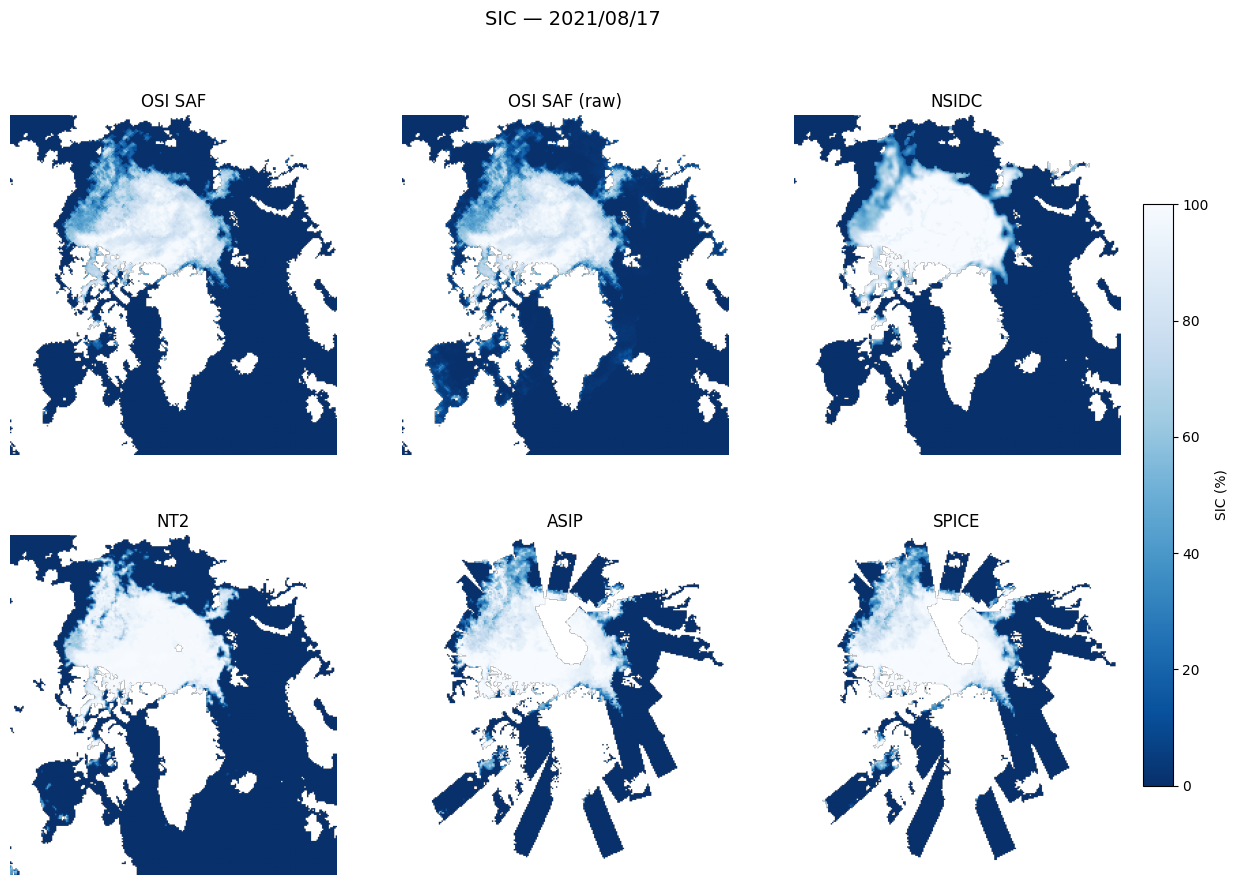

In [56]:
import matplotlib.pyplot as plt

def plot_one_day(yearmonth_samples, key=None, day_idx=0, vmin=0, vmax=100, cmap='Blues_r'):
    """
    Plot SIC for a single day across all input products.

    Parameters
    ----------
    yearmonth_samples : dict
        The dict built in the aggregation loop, keyed by 'YYYYMM'.
    key : str or None
        Which year-month to pull from (e.g. '202103'). If None, uses the
        first available key.
    day_idx : int
        Index along the stacked (day/sample) axis to plot.
    vmin, vmax : float
        Color scale limits (assumes SIC in percent, 0-100).
    cmap : str
        Colormap name.
    """
    if key is None:
        key = sorted(yearmonth_samples.keys())[0]

    data = yearmonth_samples[key]

    products = ['osisaf', 'osisaf_raw', 'nsidc', 'nt2', 'asip', 'ninna']
    titles = ['OSI SAF', 'OSI SAF (raw)', 'NSIDC', 'NT2', 'ASIP', 'SPICE']

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    im = None
    for ax, prod, title in zip(axes, products, titles):
        arr = data[prod][day_idx]
        im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap, origin='upper')
        ax.set_title(title)
        ax.axis('off')

    # fig.suptitle(f'SIC — {key}0{day_idx+1}', fontsize=14)
    fig.suptitle(f'SIC — 2021/08/17', fontsize=14)
    fig.colorbar(im, ax=axes.tolist(), fraction=0.025, pad=0.02, label='SIC (%)')
    plt.show()

    # return fig


# Example usage:
# plot_one_day(yearmonth_samples)                     # first available month, first day

plot_one_day(yearmonth_samples, key='202108', day_idx=16)

In [19]:
# for grid-cell-wise average across the years
for month in [6, 7, 8]:
    diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
    print(np.nanquantile(diff, [0.10, 0.90]))

# for all matched grid cells
for month in [6, 7, 8]:
    print(np.nanquantile(ninna_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], [0.10, 0.90]))



/tmp/ipykernel_2439510/3502667528.py:3: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)


[ 0.         18.21433438]
[ 0.         19.20323443]
[ 0.         21.71717904]
[ 0.         23.82758537]
[ 0.         24.55867061]
[ 0.         28.52997488]


#### Cartopy plot

/tmp/ipykernel_2439510/2618269772.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/2618269772.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/2618269772.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/2618269772.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/2618269772.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/2618269772.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).

Text(0.5, 0.98, 'SPICE - osisaf')

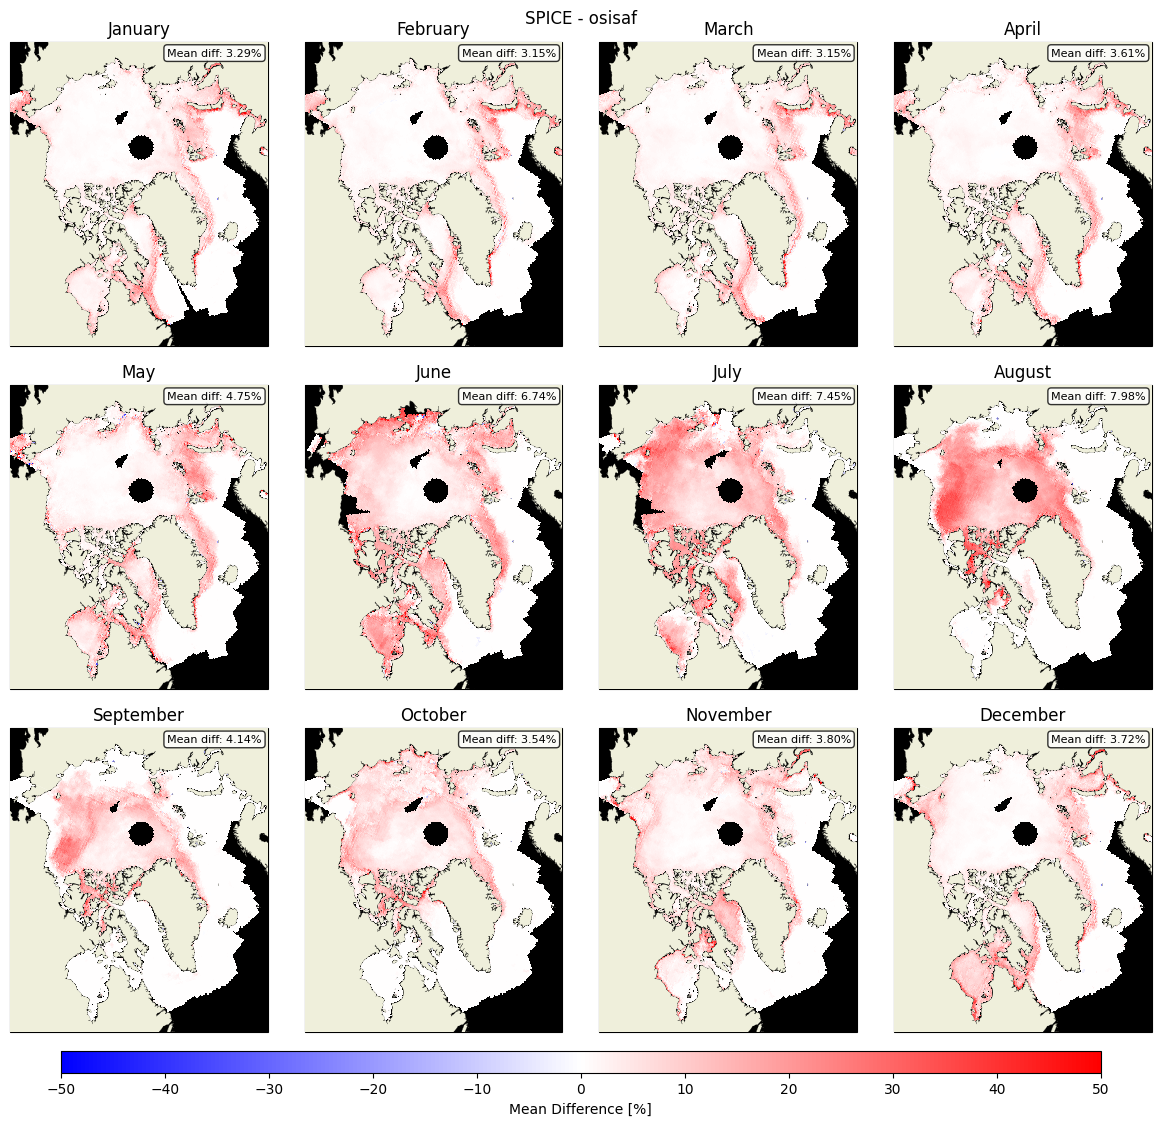

In [20]:
# Ninna - osisaf
cmap = plt.cm.bwr

fig, axes = plt.subplots(3, 4, figsize=(13, 11), subplot_kw={'projection': cartopy.crs.NorthPolarStereo(central_longitude=-65)})
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.03, hspace=0.13)
for i, ax in enumerate(axes.flat):
    if i < len(months):
        month = str(months[i]).zfill(2)
        diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)], axis=0)

        ax.set_extent([-4e6, 2e6, -2.3e6, 1.5e6], cartopy.crs.NorthPolarStereo())
        ax.add_feature(cartopy.feature.OCEAN, color='black', zorder=100)
        ax.add_feature(cartopy.feature.LAND, zorder=103)
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.1, zorder=104)
        
        im = ax.pcolormesh(lon, lat, diff, transform=cartopy.crs.PlateCarree(), zorder=102, cmap=cmap, vmin=-50, vmax=50)

        mean_diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_months[str(month).zfill(2)])
        ax.text(0.61, 0.98, f'Mean diff: {mean_diff:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=105)

        ax.set_title(f'{datetime.strptime(month, "%m").strftime("%B")}')
    else:
        ax.axis('off')

cbar_ax = fig.add_axes([0.1, 0.013, 0.8, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean Difference [%]')
cbar.set_ticks(np.arange(-50, 51, 10))

fig.suptitle('SPICE - osisaf')

#plt.savefig(f'paper_plots/asip_v_osisaf_monthly_diff_{scale}km.png', bbox_inches='tight', dpi=300)
#plt.close()

/tmp/ipykernel_2439510/1794108608.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1794108608.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1794108608.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1794108608.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1794108608.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1794108608.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill

Text(0.5, 0.98, 'SPICE - nsidc')

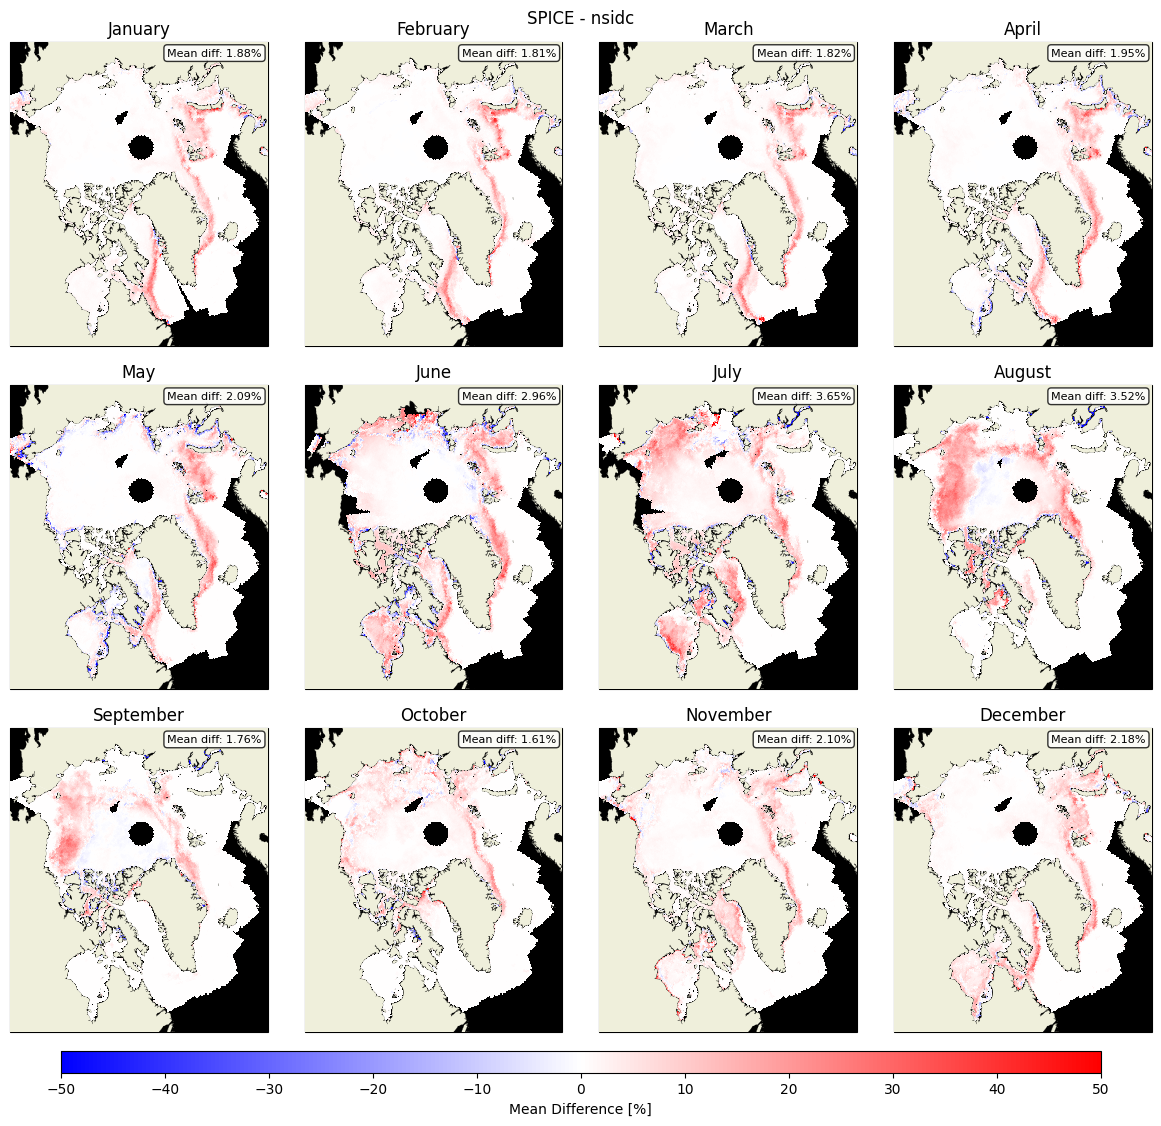

In [21]:
# Ninna - nsidc
cmap = plt.cm.bwr

fig, axes = plt.subplots(3, 4, figsize=(13, 11), subplot_kw={'projection': cartopy.crs.NorthPolarStereo(central_longitude=-65)})
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.03, hspace=0.13)
for i, ax in enumerate(axes.flat):
    if i < len(months):
        month = str(months[i]).zfill(2)
        diff = np.nanmean(ninna_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)], axis=0)

        ax.set_extent([-4e6, 2e6, -2.3e6, 1.5e6], cartopy.crs.NorthPolarStereo())
        ax.add_feature(cartopy.feature.OCEAN, color='black', zorder=100)
        ax.add_feature(cartopy.feature.LAND, zorder=103)
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.1, zorder=104)
        
        im = ax.pcolormesh(lon, lat, diff, transform=cartopy.crs.PlateCarree(), zorder=102, cmap=cmap, vmin=-50, vmax=50)

        mean_diff = np.nanmean(ninna_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)])
        ax.text(0.61, 0.98, f'Mean diff: {mean_diff:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=105)

        ax.set_title(f'{datetime.strptime(month, "%m").strftime("%B")}')
    else:
        ax.axis('off')

cbar_ax = fig.add_axes([0.1, 0.013, 0.8, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean Difference [%]')
cbar.set_ticks(np.arange(-50, 51, 10))

fig.suptitle('SPICE - nsidc')

#plt.savefig(f'paper_plots/asip_v_nsidc_monthly_diff_{scale}km.png', bbox_inches='tight', dpi=300)
#plt.close()

/tmp/ipykernel_2439510/3639918831.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/3639918831.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/3639918831.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/3639918831.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/3639918831.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/3639918831.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninn

Text(0.5, 0.98, 'SPICE - osisaf raw')

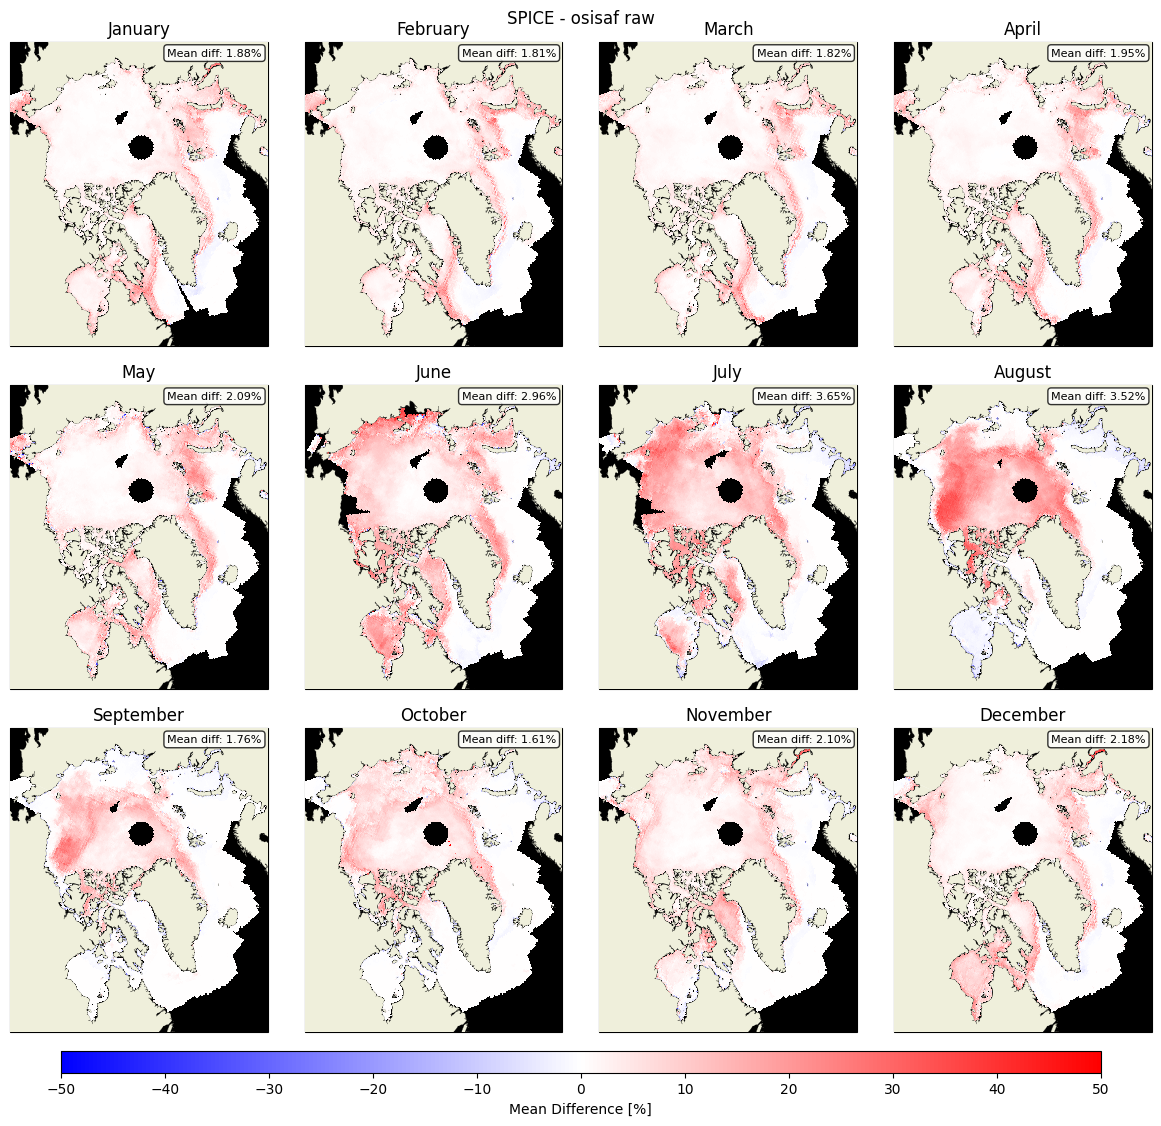

In [22]:
# Ninna - osisaf raw
cmap = plt.cm.bwr

fig, axes = plt.subplots(3, 4, figsize=(13, 11), subplot_kw={'projection': cartopy.crs.NorthPolarStereo(central_longitude=-65)})
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.03, hspace=0.13)
for i, ax in enumerate(axes.flat):
    if i < len(months):
        month = str(months[i]).zfill(2)
        diff = np.nanmean(ninna_months[str(month).zfill(2)] - osisaf_raw_months[str(month).zfill(2)], axis=0)

        ax.set_extent([-4e6, 2e6, -2.3e6, 1.5e6], cartopy.crs.NorthPolarStereo())
        ax.add_feature(cartopy.feature.OCEAN, color='black', zorder=100)
        ax.add_feature(cartopy.feature.LAND, zorder=103)
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.1, zorder=104)
        
        im = ax.pcolormesh(lon, lat, diff, transform=cartopy.crs.PlateCarree(), zorder=102, cmap=cmap, vmin=-50, vmax=50)

        mean_diff = np.nanmean(ninna_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)])
        ax.text(0.61, 0.98, f'Mean diff: {mean_diff:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=105)

        ax.set_title(f'{datetime.strptime(month, "%m").strftime("%B")}')
    else:
        ax.axis('off')

cbar_ax = fig.add_axes([0.1, 0.013, 0.8, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean Difference [%]')
cbar.set_ticks(np.arange(-50, 51, 10))

fig.suptitle('SPICE - osisaf raw')

# plt.savefig(f'paper_plots/asip_v_osisaf_raw_monthly_diff_{scale}km.png', bbox_inches='tight', dpi=300)
#plt.close()

/tmp/ipykernel_2439510/1881704808.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1881704808.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1881704808.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1881704808.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1881704808.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1881704808.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - nt2

Text(0.5, 0.98, 'SPICE - nt2')

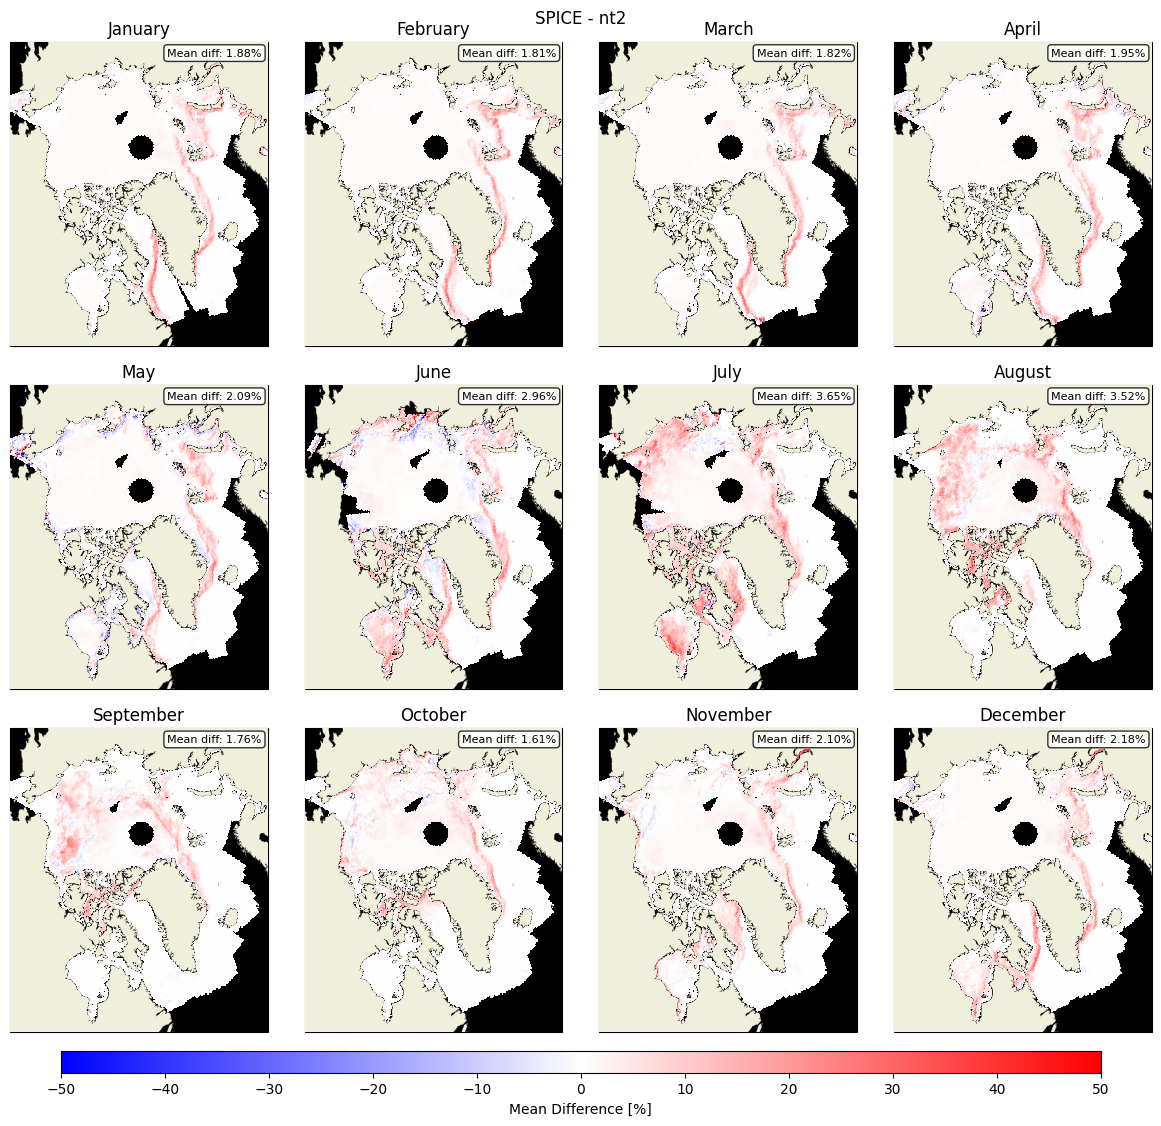

In [23]:
# Ninna - nt2
cmap = plt.cm.bwr

fig, axes = plt.subplots(3, 4, figsize=(13, 11), subplot_kw={'projection': cartopy.crs.NorthPolarStereo(central_longitude=-65)})
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.03, hspace=0.13)
for i, ax in enumerate(axes.flat):
    if i < len(months):
        month = str(months[i]).zfill(2)
        diff = np.nanmean(ninna_months[str(month).zfill(2)] - nt2_months[str(month).zfill(2)], axis=0)

        ax.set_extent([-4e6, 2e6, -2.3e6, 1.5e6], cartopy.crs.NorthPolarStereo())
        ax.add_feature(cartopy.feature.OCEAN, color='black', zorder=100)
        ax.add_feature(cartopy.feature.LAND, zorder=103)
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.1, zorder=104)
        
        im = ax.pcolormesh(lon, lat, diff, transform=cartopy.crs.PlateCarree(), zorder=102, cmap=cmap, vmin=-50, vmax=50)

        mean_diff = np.nanmean(ninna_months[str(month).zfill(2)] - nsidc_months[str(month).zfill(2)])
        ax.text(0.61, 0.98, f'Mean diff: {mean_diff:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=105)

        ax.set_title(f'{datetime.strptime(month, "%m").strftime("%B")}')
    else:
        ax.axis('off')

cbar_ax = fig.add_axes([0.1, 0.013, 0.8, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean Difference [%]')
cbar.set_ticks(np.arange(-50, 51, 10))

fig.suptitle('SPICE - nt2')

# plt.savefig(f'paper_plots/asip_v_nt2_monthly_diff_{scale}km.png', bbox_inches='tight', dpi=300)
#plt.close()

/tmp/ipykernel_2439510/1771973498.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - asip_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1771973498.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - asip_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1771973498.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - asip_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1771973498.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - asip_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1771973498.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] - asip_months[str(month).zfill(2)], axis=0)
/tmp/ipykernel_2439510/1771973498.py:9: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ninna_months[str(month).zfill(2)] 

Text(0.5, 0.98, 'SPICE - ASIP')

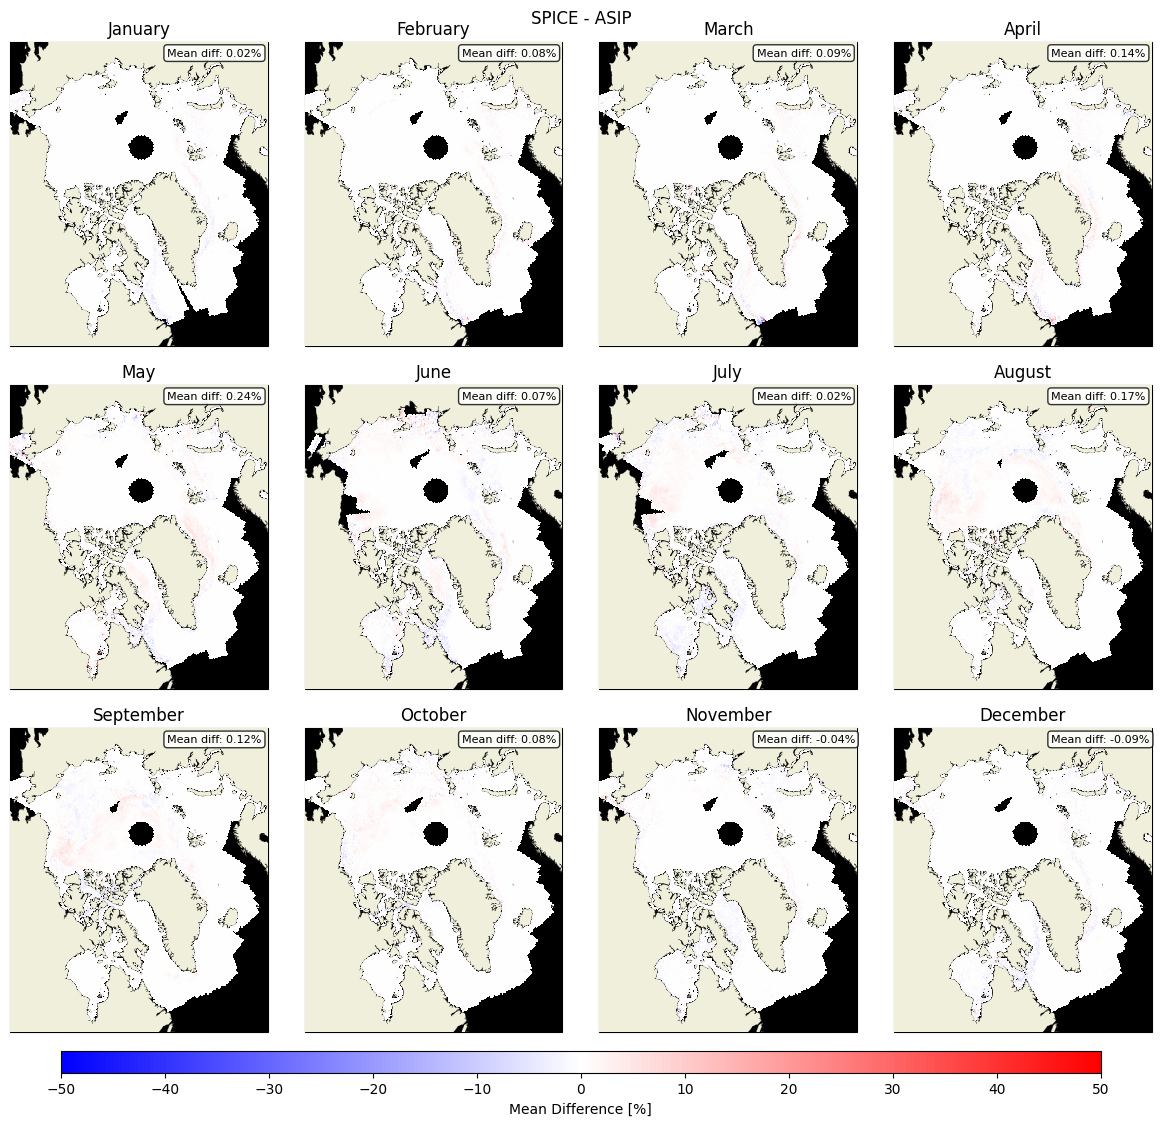

In [24]:
# Ninna - asip
cmap = plt.cm.bwr

fig, axes = plt.subplots(3, 4, figsize=(13, 11), subplot_kw={'projection': cartopy.crs.NorthPolarStereo(central_longitude=-65)})
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.03, hspace=0.13)
for i, ax in enumerate(axes.flat):
    if i < len(months):
        month = str(months[i]).zfill(2)
        diff = np.nanmean(ninna_months[str(month).zfill(2)] - asip_months[str(month).zfill(2)], axis=0)

        ax.set_extent([-4e6, 2e6, -2.3e6, 1.5e6], cartopy.crs.NorthPolarStereo())
        ax.add_feature(cartopy.feature.OCEAN, color='black', zorder=100)
        ax.add_feature(cartopy.feature.LAND, zorder=103)
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.1, zorder=104)
        
        im = ax.pcolormesh(lon, lat, diff, transform=cartopy.crs.PlateCarree(), zorder=102, cmap=cmap, vmin=-50, vmax=50)

        mean_diff = np.nanmean(ninna_months[str(month).zfill(2)] - asip_months[str(month).zfill(2)])
        ax.text(0.61, 0.98, f'Mean diff: {mean_diff:.2f}%', transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=105)

        ax.set_title(f'{datetime.strptime(month, "%m").strftime("%B")}')
    else:
        ax.axis('off')

cbar_ax = fig.add_axes([0.1, 0.013, 0.8, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Mean Difference [%]')
cbar.set_ticks(np.arange(-50, 51, 10))

fig.suptitle('SPICE - ASIP')

# plt.savefig(f'paper_plots/asip_v_nt2_monthly_diff_{scale}km.png', bbox_inches='tight', dpi=300)
#plt.close()

### Comparison with landsat

In [25]:
# Aggregate samples for all months and years

years = sorted(list(set([get_zarr_dt(zarr).year for zarr in zarrs])))
months = sorted(list(set([get_zarr_dt(zarr).month for zarr in zarrs])))

years = [2020, 2021, 2022]

yearmonth_samples = {}
for year in tqdm(years):
    for month in months:
        zarr_subset = [zarr for zarr in zarrs if get_zarr_dt(zarr).year == year and get_zarr_dt(zarr).month == month]
        asip_tmp = []
        osisaf_tmp = []
        osisaf_raw_tmp = []
        nsidc_tmp = []
        nt2_tmp = []
        ninna_tmp = []
        landsat_tmp = []
        for zarr_path in zarr_subset:
            z = zarr.open(zarr_path, mode='r')
            asip = z.datasets.asip_sic[:]
            osisaf = z.datasets.osisaf[:]
            osisaf_raw = z.datasets.osisaf_raw[:]
            nsidc = z.datasets.nsidc[:]
            nt2 = z.datasets.nt2[:]
            ninna = z.datasets.NINNA[:]
            landsat = z.datasets.landsat[:]
            valid_mask = ~(np.isnan(asip) + np.isnan(osisaf) + np.isnan(osisaf_raw) + np.isnan(nsidc) + np.isnan(nt2) + np.isnan(ninna) + np.isnan(landsat))
            if valid_mask.any(): # Appending all pixels with valid data
                asip_tmp.append(asip[valid_mask])
                osisaf_tmp.append(osisaf[valid_mask])
                osisaf_raw_tmp.append(osisaf_raw[valid_mask])
                nsidc_tmp.append(nsidc[valid_mask])
                nt2_tmp.append(nt2[valid_mask])
                ninna_tmp.append(ninna[valid_mask])
                landsat_tmp.append(landsat[valid_mask])
        
        if len(asip_tmp) > 0:
            yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {
                'asip': np.hstack(asip_tmp), 
                'osisaf': np.hstack(osisaf_tmp), 
                'osisaf_raw': np.hstack(osisaf_raw_tmp),
                'nsidc': np.hstack(nsidc_tmp), 
                'nt2': np.hstack(nt2_tmp), 
                'ninna': np.hstack(ninna_tmp),
                'landsat': np.hstack(landsat_tmp)}
        else:
            yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {
                'asip': np.array([]), 
                'osisaf': np.array([]),
                'osisaf_raw': np.array([]), 
                'nsidc': np.array([]), 
                'nt2': np.array([]),
                'ninna': np.array([]),
                'landsat': np.array([])}

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [01:22<00:00, 27.57s/it]


In [26]:
# get all samples

asip = np.hstack([yearmonth_samples[yearmonth]['asip'] for yearmonth in yearmonth_samples])
osisaf = np.hstack([yearmonth_samples[yearmonth]['osisaf'] for yearmonth in yearmonth_samples])
osisaf_raw = np.hstack([yearmonth_samples[yearmonth]['osisaf_raw'] for yearmonth in yearmonth_samples])
nsidc = np.hstack([yearmonth_samples[yearmonth]['nsidc'] for yearmonth in yearmonth_samples])
nt2 = np.hstack([yearmonth_samples[yearmonth]['nt2'] for yearmonth in yearmonth_samples])
ninna = np.hstack([yearmonth_samples[yearmonth]['ninna'] for yearmonth in yearmonth_samples])
landsat = np.hstack([yearmonth_samples[yearmonth]['landsat'] for yearmonth in yearmonth_samples])

In [27]:
# RMSE

print('RMSE')
print(f'ASIP: {root_mean_squared_error(landsat, asip)}')
print(f'OSISAF: {root_mean_squared_error(landsat, osisaf)}')
print(f'OSISAF RAW: {root_mean_squared_error(landsat, osisaf_raw)}')
print(f'NSIDC: {root_mean_squared_error(landsat, nsidc)}')
print(f'NT2: {root_mean_squared_error(landsat, nt2)}')
print(f'SPICE: {root_mean_squared_error(landsat, ninna)}')

#ASIP: 8.691811123880315
#OSISAF: 12.146302296640506
#NSIDC: 13.567394893284467

RMSE
ASIP: 8.708889477080602
OSISAF: 12.163360910489859
OSISAF RAW: 9.88944087844218
NSIDC: 13.613345385628055
NT2: 11.199132144643846
SPICE: 8.45750916802753


In [28]:
# Mean bias

print(f'ASIP: {np.mean(asip - landsat)}')
print(f'OSISAF: {np.mean(osisaf - landsat)}')
print(f'OSISAF RAW: {np.mean(osisaf_raw - landsat)}')
print(f'NSIDC: {np.mean(nsidc - landsat)}')
print(f'NT2: {np.mean(nt2 - landsat)}')
print(f'SPICE: {np.mean(ninna - landsat)}')

#ASIP: 2.4800526871937247
#OSISAF: -4.054673198041042
#NSIDC: 0.8327197390392856

ASIP: 2.4840611098762793
OSISAF: -4.067969599603497
OSISAF RAW: -2.622713127583416
NSIDC: 0.8243745267688745
NT2: 0.764307080839718
SPICE: 2.7552658919448776


### Performance across SIC bins

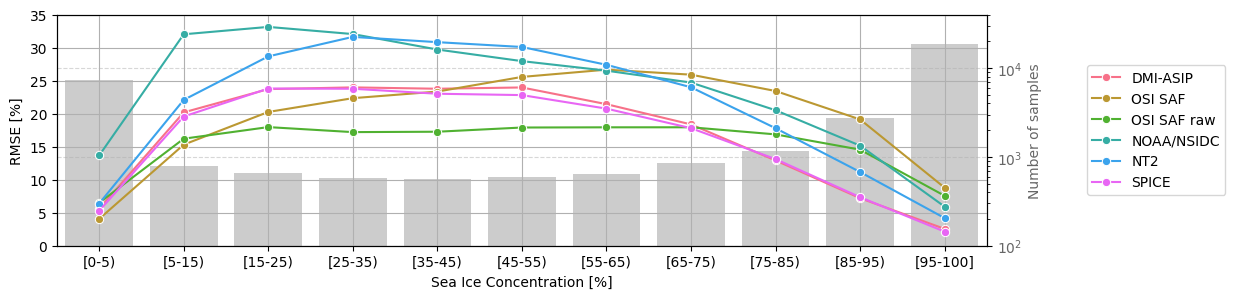

In [29]:
# Define the bins
bins = [0, 5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 100]

# Initialize lists to store RMSE and bias values for each bin
rmse_asip_bins = []
rmse_osisaf_bins = []
rmse_osisaf_raw_bins = []
rmse_nsidc_bins = []
rmse_nt2_bins = []
rmse_ninna_bins = []
bin_support = []

# Calculate RMSE for each bin
for i in range(len(bins) - 1):
    if bins[i] == 95:
        mask = (landsat >= bins[i]) & (landsat <= bins[i+1])
    else:
        mask = (landsat >= bins[i]) & (landsat < bins[i+1])

    if np.any(mask):
        rmse_asip_bins.append(root_mean_squared_error(landsat[mask], asip[mask]))
        rmse_osisaf_bins.append(root_mean_squared_error(landsat[mask], osisaf[mask]))
        rmse_osisaf_raw_bins.append(root_mean_squared_error(landsat[mask], osisaf_raw[mask]))
        rmse_nsidc_bins.append(root_mean_squared_error(landsat[mask], nsidc[mask]))
        rmse_nt2_bins.append(root_mean_squared_error(landsat[mask], nt2[mask]))
        rmse_ninna_bins.append(root_mean_squared_error(landsat[mask], ninna[mask]))
        bin_support.append(np.sum(mask))

# Create a DataFrame for bin support
data_support = {
    'Support': bin_support,
    'Bin': [f'[{bins[i]}-{bins[i+1]})' if bins[i] != 95 else f'[{bins[i]}-{bins[i+1]}]' for i in range(len(bins) - 1)]
}

df_support_bins = pd.DataFrame(data_support, columns=['Support', 'Bin'])

# Set color palette
sns.set_palette(['tab:green', 'tab:blue', 'tab:orange'])

# Create a DataFrame for plotting
data_rmse = {
    'RMSE': rmse_asip_bins + rmse_osisaf_bins + rmse_osisaf_raw_bins + rmse_nsidc_bins + rmse_nt2_bins + rmse_ninna_bins,
    'Dataset': ['DMI-ASIP'] * len(rmse_asip_bins) + ['OSI SAF'] * len(rmse_osisaf_bins) + ['OSI SAF raw'] * len(rmse_osisaf_raw_bins) + ['NOAA/NSIDC'] * len(rmse_nsidc_bins) + ['NT2'] * len(rmse_nt2_bins) + ['SPICE'] * len(rmse_ninna_bins),
    'Bin': [f'[{bins[i]}-{bins[i+1]})' if bins[i] != 95 else f'[{bins[i]}-{bins[i+1]}]' for i in range(len(bins) - 1)] * 6
}

df_rmse_bins = pd.DataFrame(data_rmse, columns=['RMSE', 'Dataset', 'Bin'])

fig, ax1 = plt.subplots(figsize=(12, 3))
sns.lineplot(x='Bin', y='RMSE', hue='Dataset', data=df_rmse_bins, marker='o', zorder=2)
ax1.set_ylabel(r'RMSE [%]')
ax1.set_xlabel('Sea Ice Concentration [%]')
ax1.set_ylim(0, 35)
ax1.grid(True, zorder=0)
# ax1.legend(loc='upper right', bbox_to_anchor=(0.95, 1))
ax1.legend(loc='center left', bbox_to_anchor=(1.1, 0.5))

ax2 = ax1.twinx()
ax2.set_zorder(0) # Send ax2 to the background
ax1.set_zorder(1) # Bring ax1 to the foreground
ax1.patch.set_visible(False) # Make ax1's background transparent to see ax2

sns.barplot(x='Bin', y='Support', data=df_support_bins, alpha=0.4, ax=ax2, color='gray')
ax2.set_yscale('log', base=10)
ax2.set_ylim(100, 40000)
ax2.set_ylabel('Number of samples', alpha=0.6)
#ax2.legend(['Support'], loc='upper right')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

for tl in ax2.get_yticklabels():
    tl.set_alpha(0.6)

# plt.savefig(f'paper_plots/rmse_plot_updated.png', bbox_inches='tight', dpi=300)

plt.show()

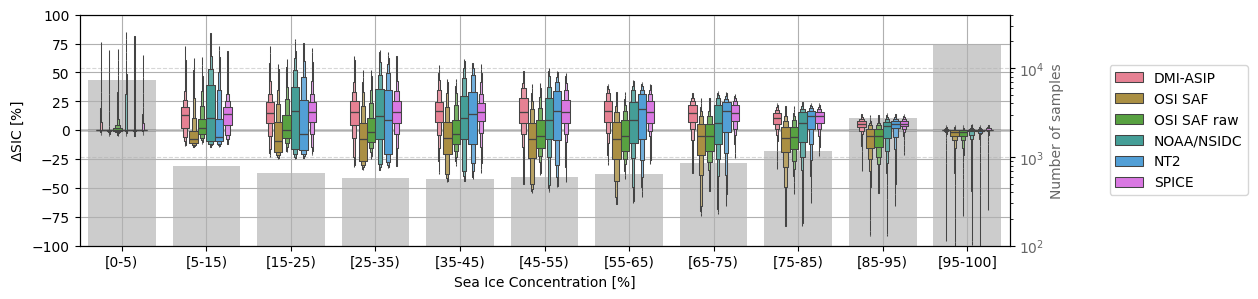

In [30]:
bias_asip_bins = []
bias_osisaf_bins = []
bias_osisaf_raw_bins = []
bias_nsidc_bins = []
bias_nt2_bins = []
bias_ninna_bins = []
bin = []

# Calculate bias for each bin
for i in range(len(bins) - 1):
    if bins[i] == 95:
        mask = (landsat >= bins[i]) & (landsat <= bins[i+1])
    else:
        mask = (landsat >= bins[i]) & (landsat < bins[i+1])

    if np.any(mask):
        bias_asip_bins.append(asip[mask] - landsat[mask])
        bias_osisaf_bins.append(osisaf[mask] - landsat[mask])
        bias_osisaf_raw_bins.append(osisaf_raw[mask] - landsat[mask])
        bias_nsidc_bins.append(nsidc[mask] - landsat[mask])
        bias_nt2_bins.append(nt2[mask] - landsat[mask])
        bias_ninna_bins.append(ninna[mask] - landsat[mask])
        bin.append([f'[{bins[i]}-{bins[i+1]})'] * np.sum(mask) if bins[i] != 95 else [f'[{bins[i]}-{bins[i+1]}]'] * np.sum(mask))

bin = [item for sublist in bin for item in sublist]

# Create a DataFrame for plotting
data_bias = {
    'Bias': np.hstack(bias_asip_bins).tolist() + np.hstack(bias_osisaf_bins).tolist() + np.hstack(bias_osisaf_raw_bins).tolist() + np.hstack(bias_nsidc_bins).tolist() + np.hstack(bias_nt2_bins).tolist() + np.hstack(bias_ninna_bins).tolist(),
    'Bin': bin * 6,
    'Dataset': ['DMI-ASIP'] * len(np.hstack(bias_asip_bins)) + ['OSI SAF'] * len(np.hstack(bias_osisaf_bins)) + ['OSI SAF raw'] * len(np.hstack(bias_osisaf_raw_bins)) + ['NOAA/NSIDC'] * len(np.hstack(bias_nsidc_bins)) + ['NT2'] * len(np.hstack(bias_nt2_bins)) + ['SPICE'] * len(np.hstack(bias_ninna_bins))
}

df_bias_bins = pd.DataFrame(data_bias, columns=['Bias', 'Bin', 'Dataset'])


fig, ax1 = plt.subplots(figsize=(12, 3))
ax1.axhline(0, color='black', lw=1, zorder=1)
sns.boxenplot(x='Bin', y='Bias', hue='Dataset', data=df_bias_bins, showfliers=False, width=0.6, ax=ax1, zorder=2) 
ax1.set_ylabel(r'$\Delta$SIC [%]')
ax1.set_xlabel('Sea Ice Concentration [%]')
ax1.set_ylim(-100, 100)
ax1.grid(True, zorder=0)
# ax1.legend(loc='upper right', bbox_to_anchor=(0.95, 1))
ax1.legend(loc='center left', bbox_to_anchor=(1.1, 0.5))

ax2 = ax1.twinx()
ax2.set_zorder(0) # Send ax2 to the background
ax1.set_zorder(1) # Bring ax1 to the foreground
ax1.patch.set_visible(False) # Make ax1's background transparent to see ax2

# Plot on the secondary axis (ax2)
sns.barplot(x='Bin', y='Support', data=df_support_bins, alpha=0.4, ax=ax2, color='gray')
ax2.set_yscale('log', base=10)
ax2.set_ylim(100, 40000)
ax2.set_ylabel('Number of samples', alpha=0.6)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

for tl in ax2.get_yticklabels():
    tl.set_alpha(0.6)

# plt.savefig(f'paper_plots/bias_plot_updated.png', bbox_inches='tight', dpi=300)

plt.show()

### Performance across months

In [31]:
# Get monthly data

asip_months, osisaf_months, osisaf_raw_months, nsidc_months, nt2_months, landsat_months = {}, {}, {}, {}, {}, {}
for month in months:
    asip_months[month] = np.hstack([yearmonth_samples[yearmonth]['asip'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    osisaf_months[month] = np.hstack([yearmonth_samples[yearmonth]['osisaf'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    osisaf_raw_months[month] = np.hstack([yearmonth_samples[yearmonth]['osisaf_raw'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    nsidc_months[month] = np.hstack([yearmonth_samples[yearmonth]['nsidc'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    nt2_months[month] = np.hstack([yearmonth_samples[yearmonth]['nt2'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    ninna_months[month] = np.hstack([yearmonth_samples[yearmonth]['ninna'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])
    landsat_months[month] = np.hstack([yearmonth_samples[yearmonth]['landsat'] for yearmonth in yearmonth_samples if yearmonth.endswith(str(month).zfill(2))])

In [32]:
min_support = 500

month_plot = []
monthly_rmse_asip, monthly_rmse_osisaf, monthly_rmse_osisaf_raw, monthly_rmse_nsidc, monthly_rmse_nt2, monthly_rmse_ninna, support = [], [], [], [], [], [], []
for month in months:
    if ninna_months[month].size >= min_support:
        monthly_rmse_asip.append(root_mean_squared_error(landsat_months[month], asip_months[month]))
        monthly_rmse_osisaf.append(root_mean_squared_error(landsat_months[month], osisaf_months[month]))
        monthly_rmse_osisaf_raw.append(root_mean_squared_error(landsat_months[month], osisaf_raw_months[month]))
        monthly_rmse_nsidc.append(root_mean_squared_error(landsat_months[month], nsidc_months[month]))
        monthly_rmse_nt2.append(root_mean_squared_error(landsat_months[month], nt2_months[month]))
        monthly_rmse_ninna.append(root_mean_squared_error(landsat_months[month], ninna_months[month]))
        support.append(ninna_months[month].size)
        month_plot.append(month - 3)

/tmp/ipykernel_2439510/3702308486.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([datetime.strptime(str(month), "%m").strftime("%B") for month in months[2:-3]])


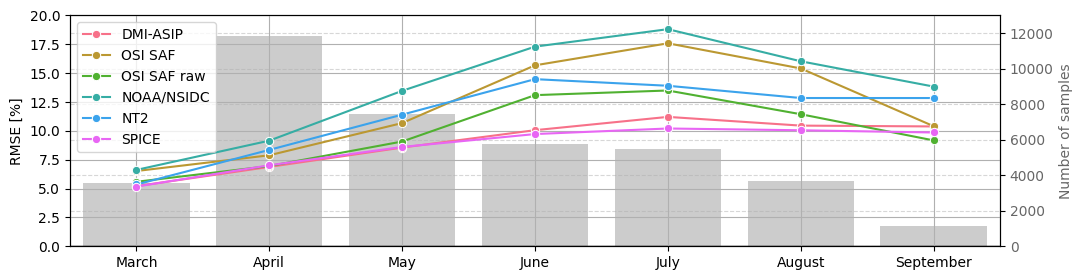

In [33]:
# Set color palette
sns.set_palette(['tab:green', 'tab:blue', 'tab:orange'])

# Create a DataFrame for bin support
data_support = {
    'Support': support,
    'Yearmonth': month_plot
}

df_support_bins = pd.DataFrame(data_support, columns=['Support', 'Yearmonth'])

# Create a DataFrame for plotting
data_rmse = {
    'RMSE': monthly_rmse_asip + monthly_rmse_osisaf + monthly_rmse_osisaf_raw + monthly_rmse_nsidc + monthly_rmse_nt2 + monthly_rmse_ninna,
    'Dataset': ['DMI-ASIP'] * len(month_plot) + ['OSI SAF'] * len(month_plot) + ['OSI SAF raw'] * len(month_plot) + ['NOAA/NSIDC'] * len(month_plot) + ['NT2'] * len(month_plot) + ['SPICE'] * len(month_plot),
    'Yearmonth': month_plot * 6
}

df_rmse_bins = pd.DataFrame(data_rmse, columns=['RMSE', 'Dataset', 'Yearmonth'])

# plt.figure(figsize=(12, 3))
# sns.lineplot(x='Yearmonth', y='RMSE', hue='Dataset', data=df_rmse_bins, marker='o')
# plt.legend(loc='upper left')
# plt.ylabel('RMSE [%]')
# plt.xlabel('')
# plt.xticks(rotation=0)
# plt.grid(True)

# # change x-axis ticks to January, February, etc.
# plt.gca().set_xticklabels([datetime.strptime(str(month), "%m").strftime("%B") for month in months[2:-3]])
# plt.ylim(0, 20)


fig, ax1 = plt.subplots(figsize=(12, 3))
ax1.axhline(0, color='black', lw=1, zorder=1)
sns.lineplot(x='Yearmonth', y='RMSE', hue='Dataset', data=df_rmse_bins, marker='o', ax=ax1, zorder=2)
ax1.set_ylabel(r'RMSE [%]')
ax1.set_xlabel('')
ax1.set_ylim(0, 20)
ax1.grid(True, zorder=0)
ax1.legend(loc='upper left') #bbox_to_anchor=(0.91, 1))
ax1.set_xticklabels([datetime.strptime(str(month), "%m").strftime("%B") for month in months[2:-3]])

ax2 = ax1.twinx()
ax2.set_zorder(0) # Send ax2 to the background
ax1.set_zorder(1) # Bring ax1 to the foreground
ax1.patch.set_visible(False) # Make ax1's background transparent to see ax2


sns.barplot(x='Yearmonth', y='Support', data=df_support_bins, alpha=0.4, ax=ax2, color='gray', order=month_plot)
ax2.set_ylim(0, 13000)
ax2.set_ylabel('Number of samples', alpha=0.6)
#ax2.legend(['Support'], loc='upper right')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

for tl in ax2.get_yticklabels():
    tl.set_alpha(0.6)

# plt.savefig(f'paper_plots/rmse_season_plot_updated.png', bbox_inches='tight', dpi=300)

plt.show()

In [34]:
min_support = 500

month_plot = []
sample_months = []
monthly_bias_asip, monthly_bias_osisaf, monthly_bias_nsidc, monthly_bias_ninna, support = [], [], [], [], []
for month in months:
    if ninna_months[month].size >= min_support:
        monthly_bias_asip.append(asip_months[month] - landsat_months[month])
        monthly_bias_osisaf.append(osisaf_months[month] - landsat_months[month])
        monthly_bias_nsidc.append(nsidc_months[month] - landsat_months[month])
        monthly_bias_ninna.append(ninna_months[month] - landsat_months[month])
        sample_months.append([month - 1]*ninna_months[month].size)
    support.append(ninna_months[month].size)
    month_plot.append(month - 1)

monthly_bias_asip = np.hstack(monthly_bias_asip).tolist()
monthly_bias_osisaf = np.hstack(monthly_bias_osisaf).tolist()
monthly_bias_nsidc = np.hstack(monthly_bias_nsidc).tolist()
monthly_bias_ninna = np.hstack(monthly_bias_ninna).tolist()
sample_months = [item for sublist in sample_months for item in sublist]


/tmp/ipykernel_2439510/758037522.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([datetime.strptime(str(month), "%m").strftime("%B") for month in months[2:-3]])


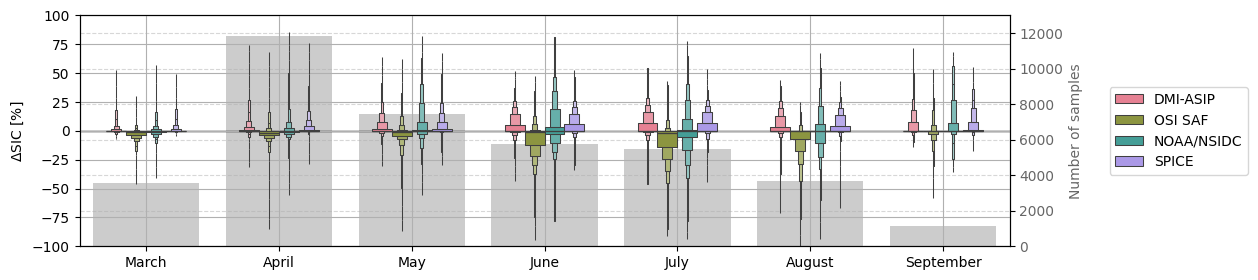

In [35]:
fig, ax1 = plt.subplots(figsize=(12, 3))

# Create a DataFrame for bin support
data_support = {
    'Support': support,
    'Yearmonth': month_plot
}

df_support_bins = pd.DataFrame(data_support, columns=['Support', 'Yearmonth'])

data_bias = {
    'Bias': monthly_bias_asip + monthly_bias_osisaf + monthly_bias_nsidc + monthly_bias_ninna,
    'Yearmonth': sample_months * 4,
    'Dataset': ['DMI-ASIP'] * len(monthly_bias_asip) + ['OSI SAF'] * len(monthly_bias_osisaf) + ['NOAA/NSIDC'] * len(monthly_bias_nsidc) + ['SPICE'] * len(monthly_bias_ninna)
}

df_bias_bins = pd.DataFrame(data_bias, columns=['Bias', 'Yearmonth', 'Dataset'])

plt.axhline(0, color='black', lw=1, zorder=1)
sns.boxenplot(x='Yearmonth', y='Bias', hue='Dataset', data=df_bias_bins, ax=ax1, order=month_plot[2:-3], width=0.6, showfliers=False, zorder=2)
ax1.set_ylabel(r'$\Delta$SIC [%]')
ax1.set_xlabel('')
ax1.set_xlim(0, 11)
ax1.set_ylim(-100, 100)
ax1.grid(True, zorder=0)
ax1.legend(loc='center left', bbox_to_anchor=(1.1, 0.5))

# change x-axis ticks to January, February, etc.
ax1.set_xticklabels([datetime.strptime(str(month), "%m").strftime("%B") for month in months[2:-3]])

ax2 = ax1.twinx()
ax2.set_zorder(0) # Send ax2 to the background
ax1.set_zorder(1) # Bring ax1 to the foreground
ax1.patch.set_visible(False) # Make ax1's background transparent to see ax2

sns.barplot(x='Yearmonth', y='Support', data=df_support_bins[2:-3], alpha=0.4, ax=ax2, color='gray', order=month_plot[2:-3])
ax2.set_ylim(0, 13000)
ax2.set_ylabel('Number of samples', alpha=0.6)
#ax2.legend(['Support'], loc='upper right')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

for tl in ax2.get_yticklabels():
    tl.set_alpha(0.6)

# plt.savefig(f'paper_plots/bias_season_plot_revised1.png', bbox_inches='tight', dpi=300)

plt.show()

## STATS

### Load data

In [36]:
# Aggregate samples for all months and years

years = sorted(list(set([get_zarr_dt(zarr).year for zarr in zarrs])))
months = sorted(list(set([get_zarr_dt(zarr).month for zarr in zarrs])))

yearmonth_samples = {}
for year in tqdm(years):
    for month in months:
        zarr_subset = [zarr for zarr in zarrs if get_zarr_dt(zarr).year == year and get_zarr_dt(zarr).month == month]
        ninna_osisaf_tmp = []
        ninna_nsidc_tmp = []
        ninna_asip_tmp = []
        osisaf_tmp = []
        nsidc_tmp = []
        asip_tmp = []
        for zarr_path in zarr_subset:
            z = zarr.open(zarr_path, mode='r')
            ninna = z.datasets.NINNA[:]
            asip = z.datasets.asip_sic[:]
            osisaf = z.datasets.osisaf[:]
            nsidc = z.datasets.nsidc[:]
            valid_mask_osisaf = ~(np.isnan(ninna) + np.isnan(osisaf))
            valid_mask_nsidc = ~(np.isnan(ninna) + np.isnan(nsidc))
            valid_mask_asip = ~(np.isnan(ninna) + np.isnan(asip))
            if valid_mask_osisaf.any(): # Appending all pixels with valid data
                ninna_osisaf_tmp.append(ninna[valid_mask_osisaf])
                osisaf_tmp.append(osisaf[valid_mask_osisaf])
            if valid_mask_nsidc.any():
                ninna_nsidc_tmp.append(ninna[valid_mask_nsidc])
                nsidc_tmp.append(nsidc[valid_mask_nsidc])
            if valid_mask_asip.any():
                ninna_asip_tmp.append(ninna[valid_mask_asip])
                asip_tmp.append(asip[valid_mask_asip])
        
        if len(ninna_osisaf_tmp) > 0:
            if len(ninna_nsidc_tmp) > 0:
                yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {'ninna_osisaf': np.hstack(ninna_osisaf_tmp), 'osisaf': np.hstack(osisaf_tmp), 'ninna_nsidc': np.hstack(ninna_nsidc_tmp), 'nsidc': np.hstack(nsidc_tmp), 'ninna_asip': np.hstack(ninna_asip_tmp), 'asip': np.hstack(asip_tmp)}
            else:
                yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {'ninna_osisaf': np.hstack(ninna_osisaf_tmp), 'osisaf': np.hstack(osisaf_tmp), 'ninna_nsidc': np.array([]), 'nsidc': np.array([]), 'ninna_asip': np.array([]), 'asip': np.array([])}
        else:
            yearmonth_samples[''.join([str(year), str(month).zfill(2)])] = {'ninna_osisaf': np.array([]), 'osisaf': np.array([]), 'ninna_nsidc': np.array([]), 'nsidc': np.array([]), 'ninna_asip': np.array([]), 'asip': np.array([])}

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:44<00:00, 14.82s/it]


In [37]:
import pandas as pd

df = pd.DataFrame()

df['date'] = yearmonth_samples.keys()
df['support_osisaf'] = [len(yearmonth_samples[yearmonth]['ninna_osisaf']) for yearmonth in yearmonth_samples.keys()]
df['support_nsidc'] = [len(yearmonth_samples[yearmonth]['ninna_nsidc']) for yearmonth in yearmonth_samples.keys()]
df['support_asip'] = [len(yearmonth_samples[yearmonth]['ninna_asip']) for yearmonth in yearmonth_samples.keys()]
df['mae_ninna_osisaf'] = [np.nanmean(np.abs(yearmonth_samples[yearmonth]['ninna_osisaf'] - yearmonth_samples[yearmonth]['osisaf'])) for yearmonth in yearmonth_samples.keys()]
df['mean_diff_ninna_osisaf'] = [np.nanmean(yearmonth_samples[yearmonth]['ninna_osisaf'] - yearmonth_samples[yearmonth]['osisaf']) for yearmonth in yearmonth_samples.keys()]
df['std_diff_ninna_osisaf'] = [np.nanstd(yearmonth_samples[yearmonth]['ninna_osisaf'] - yearmonth_samples[yearmonth]['osisaf']) for yearmonth in yearmonth_samples.keys()]
df['mae_ninna_nsidc'] = [np.nanmean(np.abs(yearmonth_samples[yearmonth]['ninna_nsidc'] - yearmonth_samples[yearmonth]['nsidc'])) for yearmonth in yearmonth_samples.keys()]
df['mean_diff_ninna_nsidc'] = [np.nanmean(yearmonth_samples[yearmonth]['ninna_nsidc'] - yearmonth_samples[yearmonth]['nsidc']) for yearmonth in yearmonth_samples.keys()]
df['std_diff_ninna_nsidc'] = [np.nanstd(yearmonth_samples[yearmonth]['ninna_nsidc'] - yearmonth_samples[yearmonth]['nsidc']) for yearmonth in yearmonth_samples.keys()]
df['mae_ninna_asip'] = [np.nanmean(np.abs(yearmonth_samples[yearmonth]['ninna_asip'] - yearmonth_samples[yearmonth]['asip'])) for yearmonth in yearmonth_samples.keys()]
df['mean_diff_ninna_asip'] = [np.nanmean(yearmonth_samples[yearmonth]['ninna_asip'] - yearmonth_samples[yearmonth]['asip']) for yearmonth in yearmonth_samples.keys()]
df['std_diff_ninna_asip'] = [np.nanstd(yearmonth_samples[yearmonth]['ninna_asip'] - yearmonth_samples[yearmonth]['asip']) for yearmonth in yearmonth_samples.keys()]
#df['standard_error_of_the_mean'] = [np.nanstd(yearmonth_samples[yearmonth]['asip'] - yearmonth_samples[yearmonth]['osisaf']) / np.sqrt(len(yearmonth_samples['201901']['asip'])) for yearmonth in yearmonth_samples.keys()]


df['ninna_osisaf_mean'] = [np.nanmean(yearmonth_samples[yearmonth]['ninna_osisaf']) for yearmonth in yearmonth_samples.keys()]
df['ninna_nsidc_mean'] = [np.nanmean(yearmonth_samples[yearmonth]['ninna_nsidc']) for yearmonth in yearmonth_samples.keys()]
df['ninna_asip_mean'] = [np.nanmean(yearmonth_samples[yearmonth]['ninna_asip']) for yearmonth in yearmonth_samples.keys()]
df['osisaf_mean'] = [np.nanmean(yearmonth_samples[yearmonth]['osisaf']) for yearmonth in yearmonth_samples.keys()]
df['nsidc_mean'] = [np.nanmean(yearmonth_samples[yearmonth]['nsidc']) for yearmonth in yearmonth_samples.keys()]
df['asip_mean'] = [np.nanmean(yearmonth_samples[yearmonth]['asip']) for yearmonth in yearmonth_samples.keys()]
df = df.dropna(subset=['mae_ninna_osisaf'])
#df = df.drop(df.index[-1]) # dropping October 2024 as it only contains a couple of days

### Valid grid cells

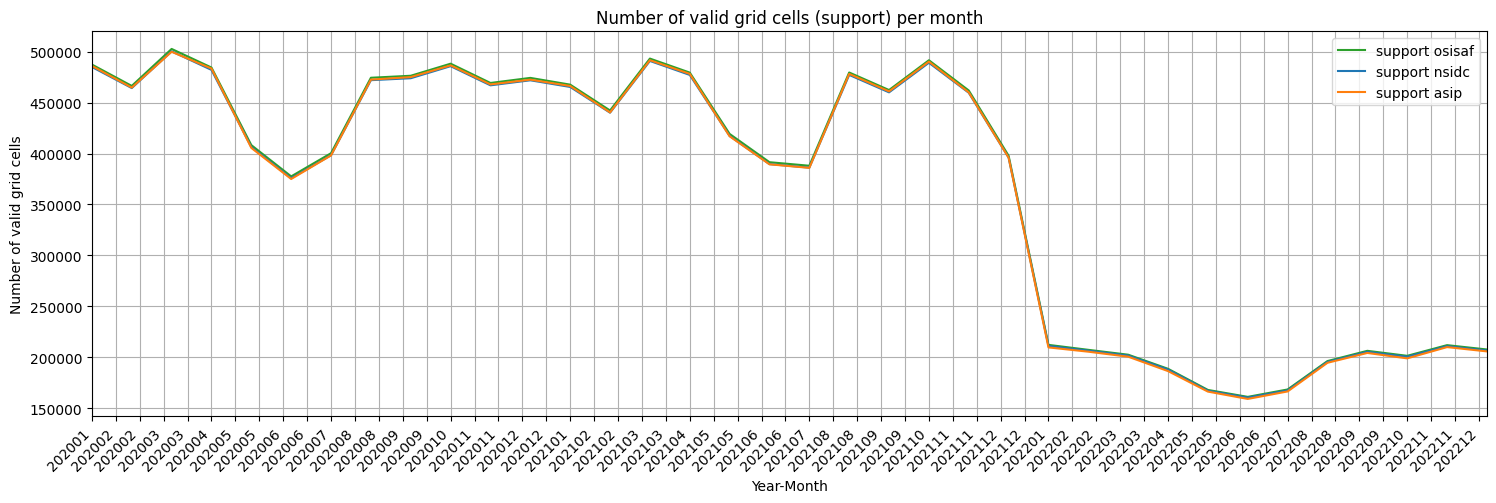

In [38]:
import matplotlib.pyplot as plt

df.loc[df.support_osisaf == 0, 'support_osisaf'] = np.nan
df.loc[df.support_nsidc == 0, 'support_nsidc'] = np.nan
df.loc[df.support_asip == 0, 'support_asip'] = np.nan

plt.figure(figsize=(18, 5))

plt.plot(df['date'], df['support_osisaf'], label='support osisaf')
plt.plot(df['date'], df['support_nsidc'], label='support nsidc')
plt.plot(df['date'], df['support_asip'], label='support asip')

plt.grid(axis='y', which='both')
plt.grid(axis='x', which='both')

plt.title('Number of valid grid cells (support) per month')
plt.xticks(rotation=45, ha='right')
plt.xlim(0, len(df) - 1)
plt.xlabel('Year-Month')
plt.ylabel('Number of valid grid cells')
plt.legend()

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=60))

#plt.savefig(f'plots/asip_v_osisaf_monthly_support_{scale}km.png', bbox_inches='tight', dpi=300)

### Monthly MAE

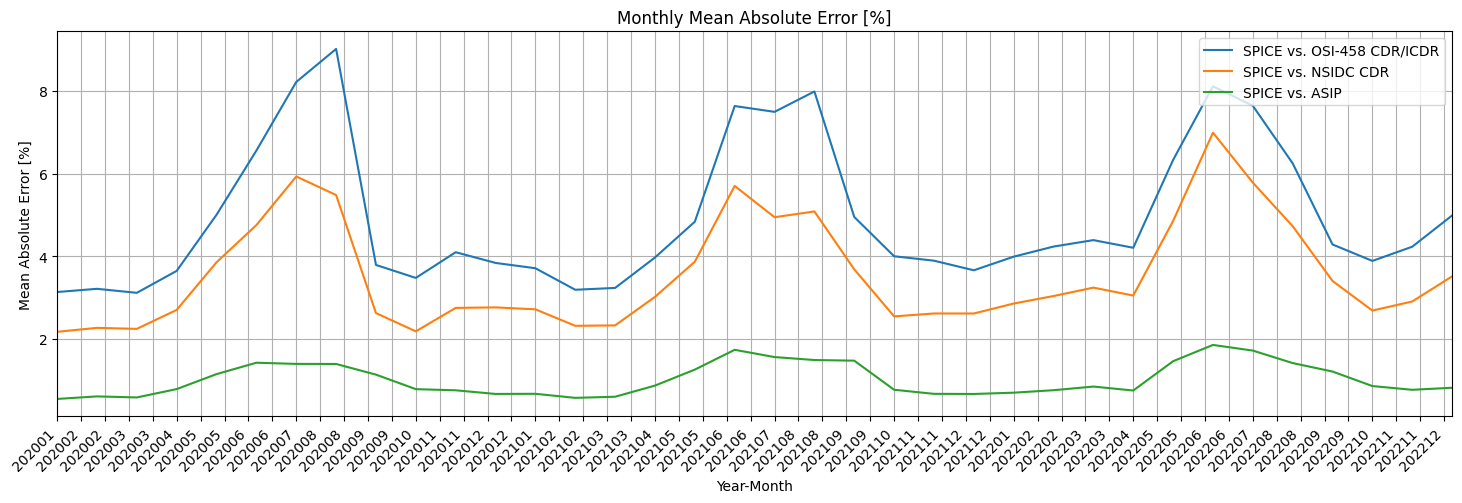

In [39]:
import matplotlib.pyplot as plt

#minimum_support = 30000

plt.figure(figsize=(18, 5))

#df.loc[df.support < minimum_support, 'asip_mae'] = np.nan
#df.loc[df.support < minimum_support, 'osisaf_mae'] = np.nan

color = 'tab:blue'
plt.plot(df.date, df.mae_ninna_osisaf, label='SPICE vs. OSI-458 CDR/ICDR', color=color)
color = 'tab:orange'
plt.plot(df.date, df.mae_ninna_nsidc, label='SPICE vs. NSIDC CDR', color=color)
color = 'tab:green'
plt.plot(df.date, df.mae_ninna_asip, label='SPICE vs. ASIP', color=color)

plt.grid(axis='y', which='both')
plt.grid(axis='x', which='both')

plt.title(f'Monthly Mean Absolute Error [%]')
plt.xticks(rotation=45, ha='right')
plt.xlim(0, len(df) - 1)
plt.xlabel('Year-Month')
plt.ylabel('Mean Absolute Error [%]')
plt.legend()

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=60))

#plt.savefig(f'plots/asip_v_osisaf_monthly_mae_{scale}km.png', bbox_inches='tight', dpi=300)

### Mean diff

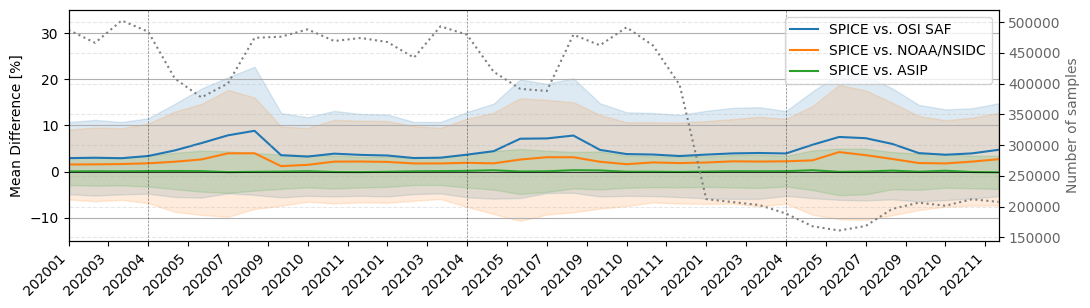

In [40]:
import matplotlib.pyplot as plt

#minimum_support = 30000

plt.figure(figsize=(12, 3))

#df.loc[df.support < minimum_support, 'asip_mae'] = np.nan
#df.loc[df.support < minimum_support, 'osisaf_mae'] = np.nan

fill_alpha = 0.15
std_alpha = 0.3
std_symbol = '--'

color = 'tab:blue'
plt.plot(df.date, df.mean_diff_ninna_osisaf, label='SPICE vs. OSI SAF', color=color)
#plt.plot(df.date, df.mean_diff_ninna_osisaf + df.std_diff_ninna_osisaf, std_symbol, color=color, alpha=std_alpha)
#plt.plot(df.date, df.mean_diff_ninna_osisaf - df.std_diff_ninna_osisaf, std_symbol, color=color, alpha=std_alpha)
plt.fill_between(df.date, df.mean_diff_ninna_osisaf - df.std_diff_ninna_osisaf, df.mean_diff_ninna_osisaf + df.std_diff_ninna_osisaf, color=color, alpha=fill_alpha)
color = 'tab:orange'
plt.plot(df.date, df.mean_diff_ninna_nsidc, label='SPICE vs. NOAA/NSIDC', color=color)
#plt.plot(df.date, df.mean_diff_ninna_nsidc + df.std_diff_ninna_nsidc, std_symbol, color=color, alpha=std_alpha)
#plt.plot(df.date, df.mean_diff_ninna_nsidc - df.std_diff_ninna_nsidc, std_symbol, color=color, alpha=std_alpha)
plt.fill_between(df.date, df.mean_diff_ninna_nsidc - df.std_diff_ninna_nsidc, df.mean_diff_ninna_nsidc + df.std_diff_ninna_nsidc, color=color, alpha=fill_alpha)

color = 'tab:green'
plt.plot(df.date, df.mean_diff_ninna_asip, label='SPICE vs. ASIP', color=color)
plt.fill_between(df.date, df.mean_diff_ninna_asip - df.std_diff_ninna_asip, df.mean_diff_ninna_asip + df.std_diff_ninna_asip, color=color, alpha=fill_alpha)

# add horizontal line at 0
plt.axhline(0, color='black', lw=0.5)

# add vertical lines for each year
for i in range(0, len(df), 12):
     plt.axvline(i + 3, color='black', linewidth=0.5, linestyle='--', alpha=0.5)

plt.grid(axis='y', which='both')
#plt.grid(axis='x', which='both')

#plt.title(f'Monthly Mean Difference')
plt.xticks(rotation=45, ha='right')
plt.xlim(0, len(df) - 1)
plt.ylim(-15, 35)
plt.legend(loc='upper right')

# add y label
plt.ylabel('Mean Difference [%]')

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=30))

# Plot support as a bar plot on a new y-axis
ax2 = plt.gca().twinx()
ax2.plot(df.date, df.support_osisaf, color='gray', alpha=1, label='Support OSI SAF', zorder=-5, linestyle=':') 
#ax2.bar(df.index, df.support_nsidc, color='tab:orange', alpha=0.2, label='Support NSIDC')
ax2.set_ylabel('Number of samples', alpha=0.6)
#ax2.set_yscale('log')
ax2.grid(True, axis='y', linestyle='--', alpha=0.3)

# Adjust transparency of y-axis tick labels
for tl in ax2.get_yticklabels():
     tl.set_alpha(0.6)

# plt.savefig(f'paper_plots/asip_v_osisaf_and_nsidc_monthly_mean_diff_revised1.png', bbox_inches='tight', dpi=300)

### Plots

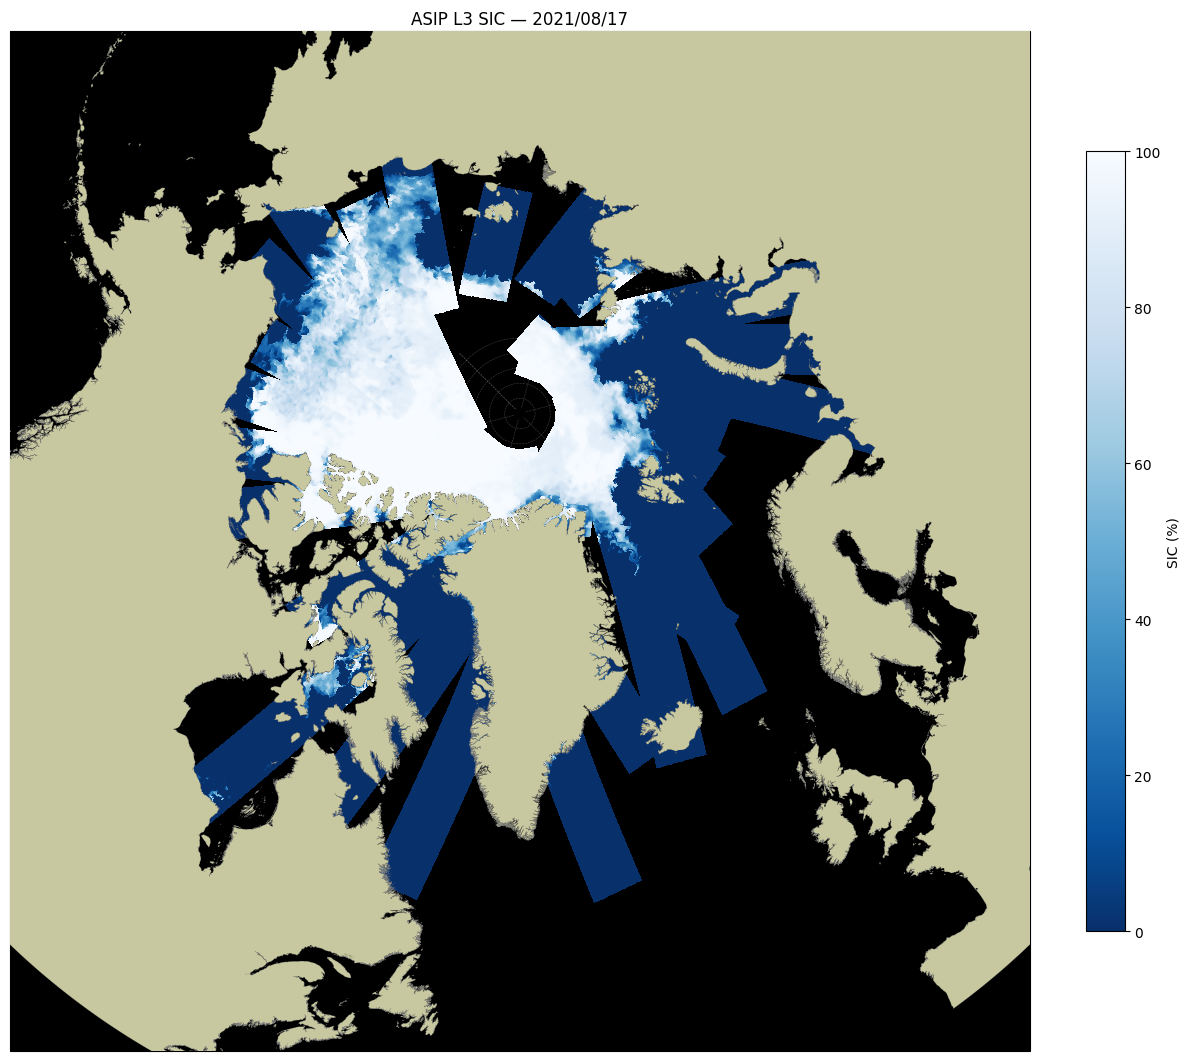

In [54]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import geopandas as gpd
from pyproj import Transformer
import sys
sys.path.insert(0, '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI')

from Code.lib.predict.NorthPolStere import NorthPolStere

shp = gpd.read_file('/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code/lib/predict/arctic_shp/op_str_maps_circum_polar_40_EPSG3411.shp')
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3411', always_xy=True)

DATE     = '2021/08/17'
y, m, d  = DATE.split('/')
ymin, ymax = 7500, 20000
xmin, xmax = 1500, 13500

# ── Load directly from the date file ─────────────────────────────────────────
asip_file = f'/dmidata/projects/asip-cms/reproc/mosaics/level3_0500m_v1/dmi_asip_seaice_mosaic_arc_l3_{y}{m}{d}.nc'
ds  = xr.open_dataset(asip_file)
sic = ds['sic'][0, ymin:ymax, xmin:xmax].values.astype(np.float32)
lat = ds['lat'][ymin:ymax, xmin:xmax].values
lon = ds['lon'][ymin:ymax, xmin:xmax].values
ds.close()

sic[sic > 100] = np.nan
sic[sic < 0]   = np.nan

# # Downsample 500m → 25km for plotting speed
# step = 50
# sic_ds  = sic[::step, ::step]
# lat_ds  = lat[::step, ::step]
# lon_ds  = lon[::step, ::step]

sic_ds  = sic
lat_ds  = lat
lon_ds  = lon

x_grid, y_grid = transformer.transform(lon_ds, lat_ds)

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap = plt.cm.Blues_r.copy()
cmap.set_bad('none')

proj = NorthPolStere()
fig, ax = plt.subplots(1, 1, figsize=(12, 12), subplot_kw={'projection': proj})
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
ax.set_facecolor('black')

ax.pcolormesh(x_grid, y_grid, sic_ds,
              transform=NorthPolStere(),
              cmap=cmap, vmin=0, vmax=100,
              shading='auto', zorder=4)

shp.plot(ax=ax, facecolor='#c8c8a0', edgecolor='gray',
         linewidth=0.1, zorder=5)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                  alpha=0.5, linestyle='--')
gl.top_labels   = False
gl.right_labels = False

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=100))
sm.set_array([])
plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.05, label='SIC (%)', shrink=0.7)
ax.set_title(f'ASIP L3 SIC — {DATE}', fontsize=12)
plt.tight_layout()
plt.show()

/dmidata/users/nili/miniforge3/envs/master/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
/dmidata/users/nili/miniforge3/envs/master/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)
/dmidata/users/nili/miniforge3/envs/master/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonic

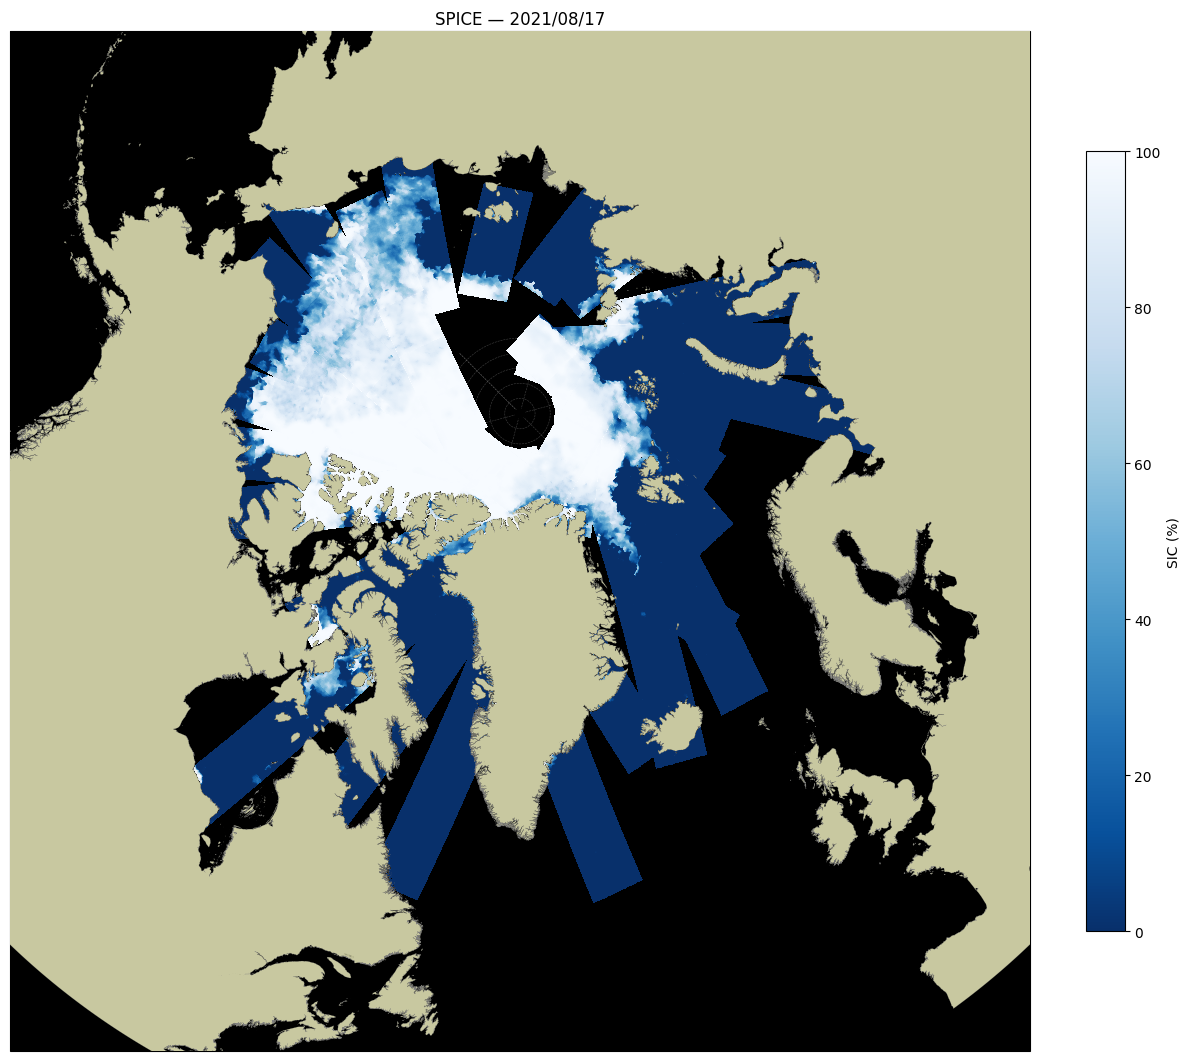

In [55]:
import os
import glob
import numpy as np
import rioxarray
import xarray as xr
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import RectBivariateSpline
import zipfile
import xml.etree.ElementTree as ET
from pyproj import Transformer
import geopandas as gpd
import sys
sys.path.insert(0, '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI')

from Code.lib.predict.NorthPolStere import NorthPolStere

shp = gpd.read_file('/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code/lib/predict/arctic_shp/op_str_maps_circum_polar_40_EPSG3411.shp')

transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3411', always_xy=True)
# ── Config ────────────────────────────────────────────────────────────────────
DATE     = '2021/08/17'
SIC_BASE  = '/home/nili/ninna_msc_output'
y, m, d   = DATE.split('/')
sic_files = sorted(glob.glob(os.path.join(SIC_BASE, y, m, d, '*.nc')))
# print(xr.open_dataset(sic_files[0]))
cmap = plt.cm.Blues_r.copy()
cmap.set_bad('none')

proj = NorthPolStere()
fig, ax = plt.subplots(1, 1, figsize=(12, 12), subplot_kw={'projection': proj})
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
ax.set_facecolor('black')

for sic_path in sic_files:
    try:
        ds     = xr.open_dataset(sic_path)
        sic    = ds['SIC_pred'].values.astype(np.float32)
        lats   = np.array(ds.attrs['gcp_lats'])
        lons   = np.array(ds.attrs['gcp_lons'])
        lines  = np.array(ds.attrs['gcp_lines'])
        pixels = np.array(ds.attrs['gcp_pixels'])
        ds.close()

        grid_h, grid_w = sic.shape

        n_lines  = len(np.unique(lines))
        n_pixels = len(np.unique(pixels))

        # Project GCP lon/lat → x/y in EPSG:3411
        gcp_x, gcp_y = transformer.transform(
            lons.reshape(n_lines, n_pixels),
            lats.reshape(n_lines, n_pixels)
        )

        # Interpolate projected GCPs to full grid
        x_interp = RectBivariateSpline(
            lines.reshape(n_lines, n_pixels)[:, 0],
            pixels.reshape(n_lines, n_pixels)[0, :],
            gcp_x)
        y_interp = RectBivariateSpline(
            lines.reshape(n_lines, n_pixels)[:, 0],
            pixels.reshape(n_lines, n_pixels)[0, :],
            gcp_y)

        row_coords = np.linspace(0, lines.max(), grid_h)
        col_coords = np.linspace(0, pixels.max(), grid_w)
        x_scene    = x_interp(row_coords, col_coords)
        y_scene    = y_interp(row_coords, col_coords)

        sic_valid = sic.copy()
        sic_valid[sic >= 254] = np.nan

        ax.pcolormesh(x_scene, y_scene, sic_valid,
                      cmap=cmap, vmin=0, vmax=100,
                      shading='auto', zorder=4)

    except Exception as e:
        print(f'Error processing {os.path.basename(sic_path)}: {e}')

shp.plot(ax=ax, facecolor='#c8c8a0', edgecolor='gray',
         linewidth=0.1, zorder=5)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                  alpha=0.5, linestyle='--')
gl.top_labels   = False
gl.right_labels = False

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=100))
sm.set_array([])
plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.05, label='SIC (%)', shrink=0.7)
ax.set_title(f'SPICE — {DATE}', fontsize=12)
plt.tight_layout()
plt.show()